STOCK MARKET DATASET:


Dataset:https://www.kaggle.com/datasets/ziya07/stock-market-dataset/data



SECTION A — DATASET & EDA

A1. Dataset Loading & Audit

In [29]:
#importing libraries

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#imports for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#imports for classification track
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

#imports for reports
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    classification_report
)

In [31]:
#loading datasets

df = pd.read_csv("stock_data.csv")

In [3]:
#displays the first rows
print(df.head())
print()
#displays the dataset shape
print("No: of rows:", df.shape[0])  
print("No: of columns:", df.shape[1])
print()
#displays column datatypes
print(df.dtypes)  
 

       Open     Close      High       Low    Volume       RSI      MACD  \
0  0.374639  0.374780  0.373510  0.378390  0.298909  0.847286  0.741715   
1  0.950982  0.937746  0.938422  0.946158  0.094805  0.494543  0.881343   
2  0.732198  0.719825  0.723644  0.723158  0.126348  0.195471  0.463179   
3  0.598823  0.599865  0.596973  0.605322  0.180662  0.736684  0.289076   
4  0.156053  0.163410  0.155891  0.166084  0.203646  0.418698  0.318761   

   Bollinger_Upper  Bollinger_Lower  Sentiment_Score  GDP_Growth  \
0         0.367146         0.366420         0.877177    0.580868   
1         0.938396         0.935640         0.907192    0.527044   
2         0.710666         0.702300         0.378363    0.351052   
3         0.593793         0.586936         0.231614    0.493274   
4         0.164158         0.156355         0.191642    0.365116   

   Inflation_Rate  Target  
0        0.038604       0  
1        0.108908       0  
2        0.432540       0  
3        0.946349       0  


In [4]:
# display missing Values
print(df.isnull().sum())
print()
# displays the number of duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Open               0
Close              0
High               0
Low                0
Volume             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
Sentiment_Score    0
GDP_Growth         0
Inflation_Rate     0
Target             0
dtype: int64

Number of duplicate rows: 0


In [5]:
# Target Distribution - classification target - TARGET
print(df["Target"].value_counts())

Target
0    9405
1     595
Name: count, dtype: int64


A2: EDA Visualisations


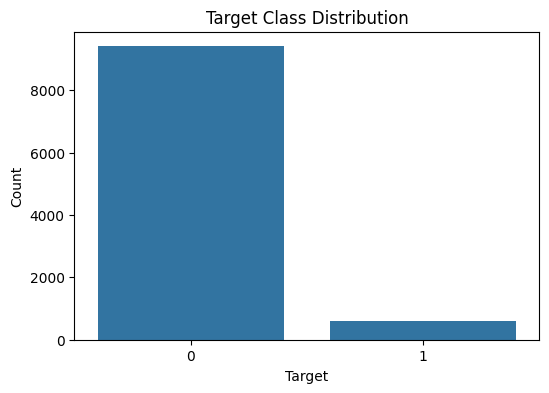

In [6]:
#Countplot for Target class distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Target")

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

Observation:

The target distribution shows the number ofn observations belonging to each class. This can be used to determine whether the classification dataset is balanced or whether one class is more frequent than the other.

This is important as severe class imbalance can affect the classification model performance 

class 0: More observations

class 1: Less observations

This indicates imbalance. Therefore accuracy alone may not fully represent classification performance. Precision, recall, F1-score and ROC_AUC should also be considered.

In [7]:
# Identifying numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

for i in numeric_columns:
    print(i)

Open
Close
High
Low
Volume
RSI
MACD
Bollinger_Upper
Bollinger_Lower
Sentiment_Score
GDP_Growth
Inflation_Rate
Target


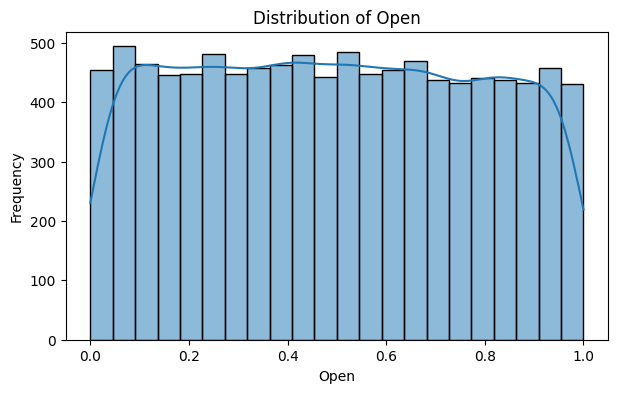

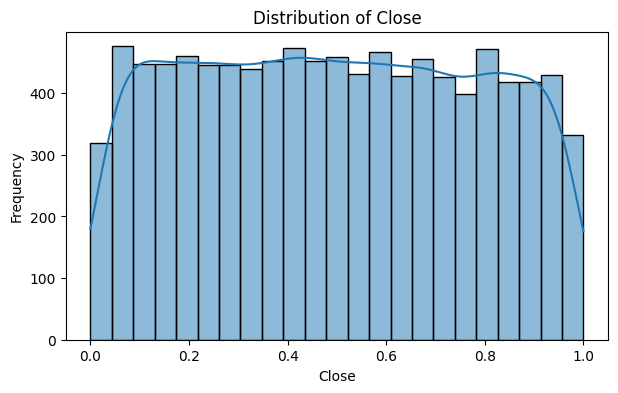

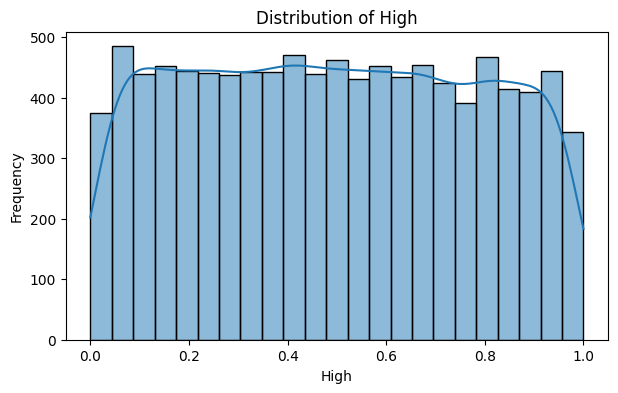

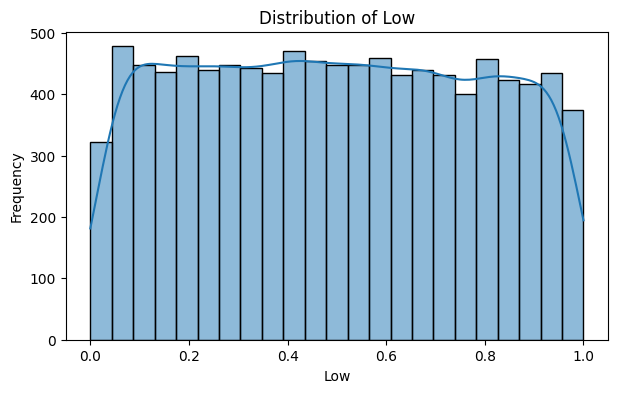

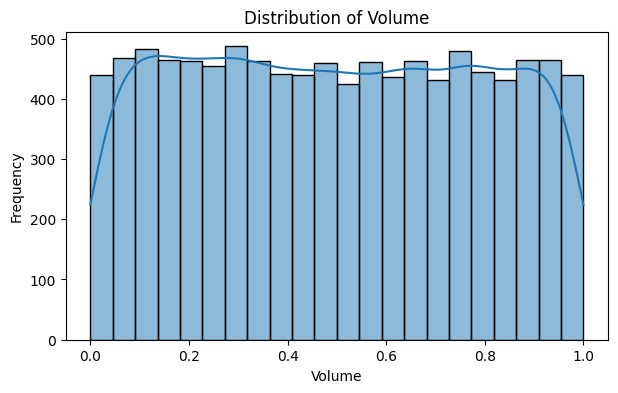

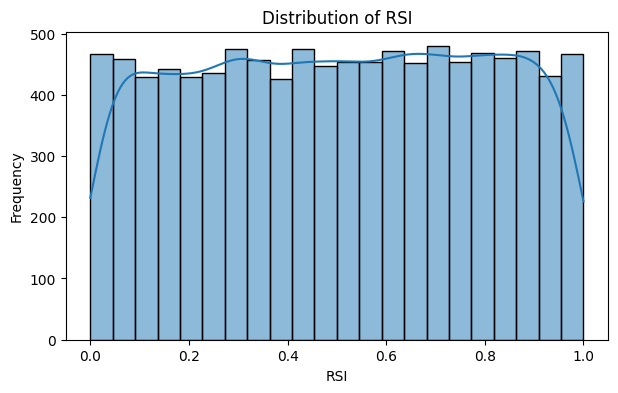

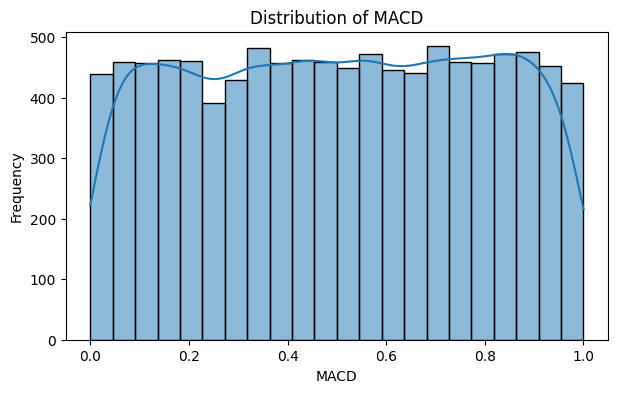

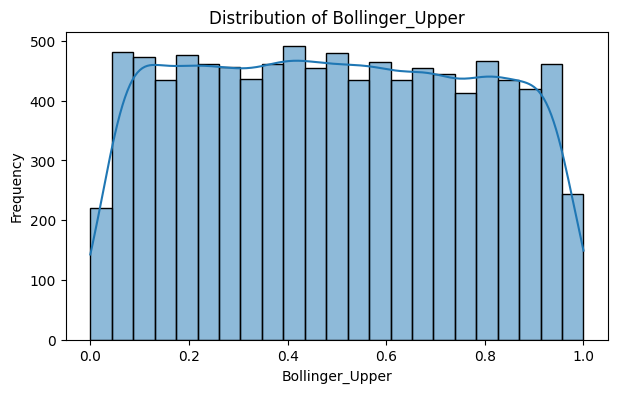

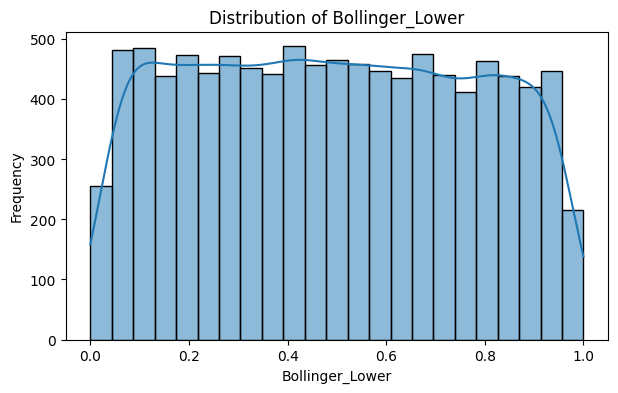

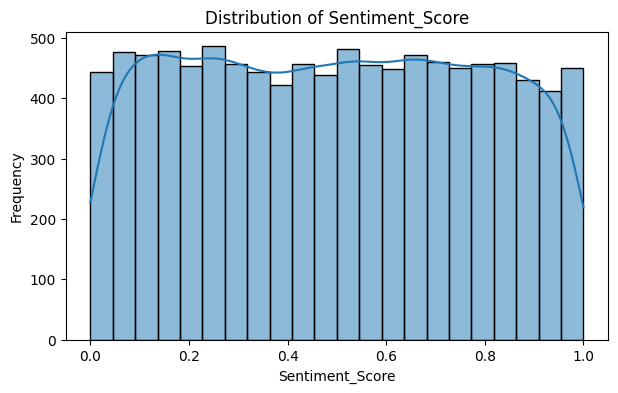

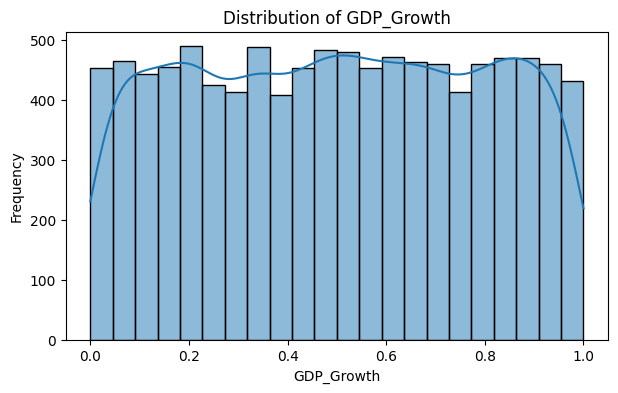

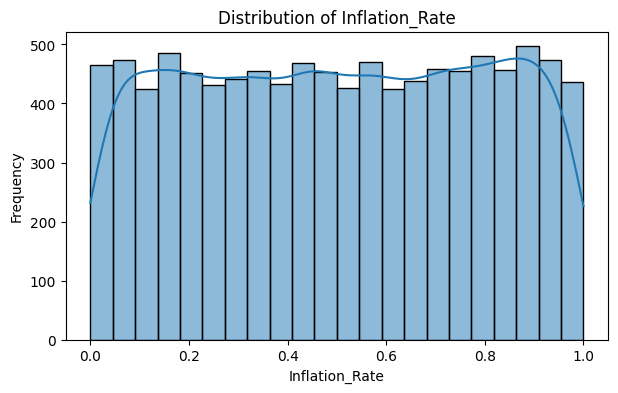

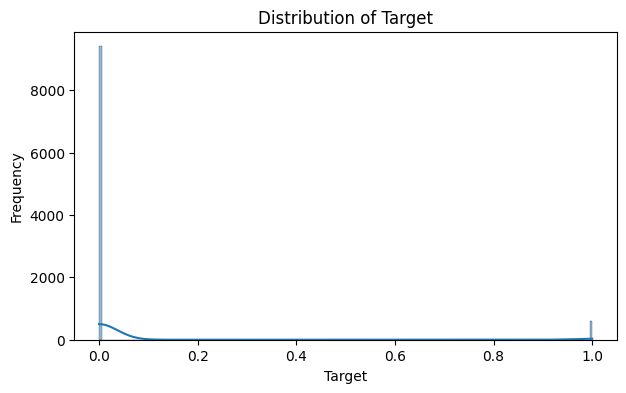

In [8]:
# Histplot for every numerical feature

for column in numeric_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

Observation: 

The distribution plots show the spread and shape of the numerical features. Some variables may show approximately symmetric distributions, while others may be skewed. Features with strong skewness or extreme values may require scaling or appropriate preprocessing before applying machine-learning algorithms.

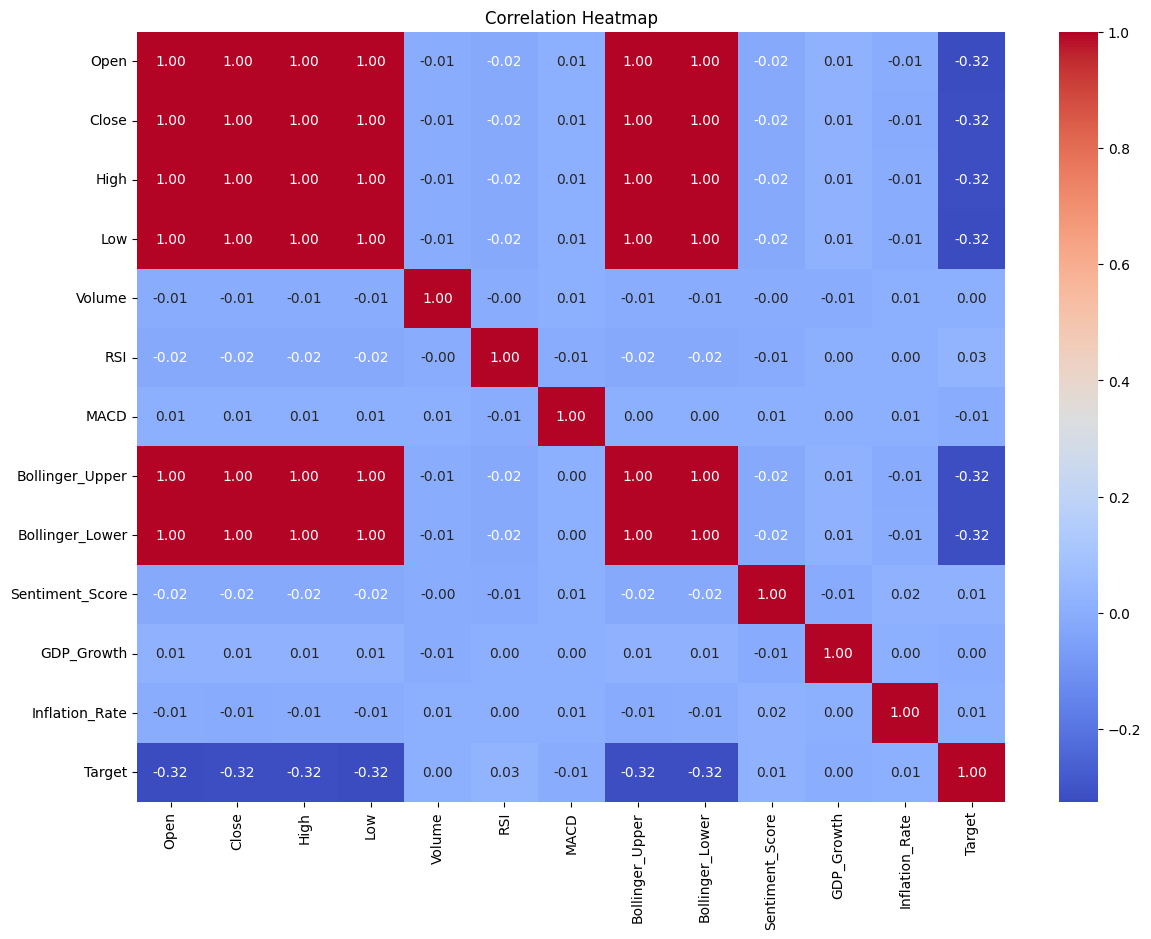

In [9]:
# Correlation Heatmap

plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Observation: 

The correlation heatmap shows the strength and direction of relationships between numerical variables. Highly positive correlations indicate that two variables tend to increase together, while negative correlations indicate an inverse relationship. Strong correlations between predictors should be considered when interpreting model coefficients and feature importance.

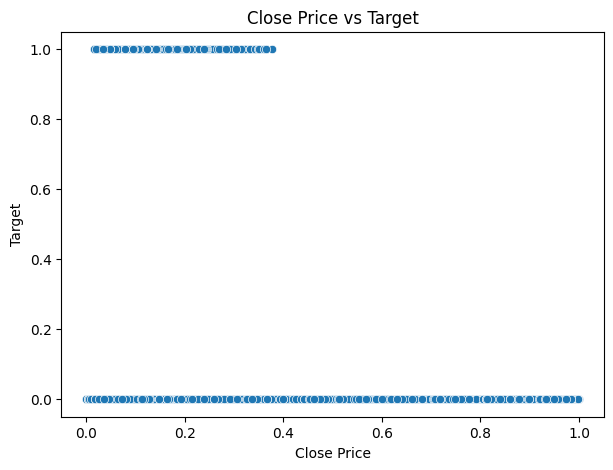

In [10]:
# Scatter plot showing the relationship between the closing price and target class

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Close",
    y="Target"
)

plt.title("Close Price vs Target")
plt.xlabel("Close Price")
plt.ylabel("Target")

plt.show()

Observation:

The scatter plot shows the relationship between the closing price and the target class. Since the target is categorical/binary, the observations appear in distinct horizontal levels corresponding to the target classes. The degree of overlap between the classes provides an initial indications of how well the closing price alone may distinguish the target classes.

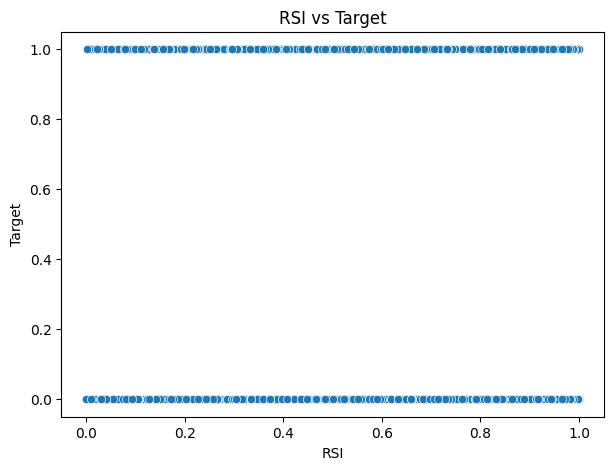

In [11]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="RSI",
    y="Target"
)

plt.title("RSI vs Target")
plt.xlabel("RSI")
plt.ylabel("Target")

plt.show()

Observations:

SECTION B - PREPROCESSING & FEATURE ENGINEERING

B1: Data Cleaning

In [12]:
X = df.drop(columns=["Target"])
y = df["Target"]

print("Features:", X.columns.tolist())
print()
print("Target:", y.name)

Features: ['Open', 'Close', 'High', 'Low', 'Volume', 'RSI', 'MACD', 'Bollinger_Upper', 'Bollinger_Lower', 'Sentiment_Score', 'GDP_Growth', 'Inflation_Rate']

Target: Target


In [13]:
# handles missing values
# replace with median

X = X.fillna(X.median(numeric_only=True))

In [14]:
# makes sure only numerical columns remain

X = X.select_dtypes(include=np.number)

In [15]:
# checking if
#    (i) the columns have been removed or not
#    (ii) missing values are handled
#    (iii) only numerical columns remain

print(X.shape)
print(X.columns)

(10000, 12)
Index(['Open', 'Close', 'High', 'Low', 'Volume', 'RSI', 'MACD',
       'Bollinger_Upper', 'Bollinger_Lower', 'Sentiment_Score', 'GDP_Growth',
       'Inflation_Rate'],
      dtype='str')


B2: Encoding, Scaling & Splitting

In [16]:
# train-test split - separate features and target
# sicne target is binary, we can use a stratified split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 12)
Testing set: (2000, 12)


In [25]:
# Scaling - Standard Scaler & Encoding - OneHot Encoder

numeric_columns = X_train.select_dtypes(include=np.number).columns
categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

B3: Feature Engineering

In [28]:
# Feature Engineering - Price Range

print(df.columns.tolist()) # checking whether the dataset contains High and Low
print()
df["Price_Change_Percent"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100
print(df.head())

['Open', 'Close', 'High', 'Low', 'Volume', 'RSI', 'MACD', 'Bollinger_Upper', 'Bollinger_Lower', 'Sentiment_Score', 'GDP_Growth', 'Inflation_Rate', 'Target', 'Price_Change_Percent']

       Open     Close      High       Low    Volume       RSI      MACD  \
0  0.374639  0.374780  0.373510  0.378390  0.298909  0.847286  0.741715   
1  0.950982  0.937746  0.938422  0.946158  0.094805  0.494543  0.881343   
2  0.732198  0.719825  0.723644  0.723158  0.126348  0.195471  0.463179   
3  0.598823  0.599865  0.596973  0.605322  0.180662  0.736684  0.289076   
4  0.156053  0.163410  0.155891  0.166084  0.203646  0.418698  0.318761   

   Bollinger_Upper  Bollinger_Lower  Sentiment_Score  GDP_Growth  \
0         0.367146         0.366420         0.877177    0.580868   
1         0.938396         0.935640         0.907192    0.527044   
2         0.710666         0.702300         0.378363    0.351052   
3         0.593793         0.586936         0.231614    0.493274   
4         0.164158         

Price_Change_Percent represents the percentage movement between the opening and closing prices. This provides the normalized measure of daily price movement and can help the classification models distinguish between different market conditions.

SECTION D - CLASSIFICATION TRACK, PART A

D1: Implementation

In [27]:
#function for evaluation - avoids writing the same evaluation code 10 times

results = []

def evaluate_model(name, model):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Algorithm": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    print("\n", name)
    print("-----------------------------")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)
    print("ROC-AUC  :", roc_auc)

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    return model

In [20]:
#

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model = evaluate_model(
    "Logistic Regression",
    logistic_model
)


 Logistic Regression
-----------------------------
Accuracy : 0.942
Precision: 0.9453690535803705
Recall   : 0.942
F1-Score : 0.9152936869604916
ROC-AUC  : 0.9436514637753027

Confusion Matrix:
[[1881    0]
 [ 116    3]]


In [21]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model = evaluate_model(
    "K-Nearest Neighbors",
    knn_model
)


for k in [3, 5, 7, 9, 11]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    print("k =", k, "Accuracy =", accuracy)


 K-Nearest Neighbors
-----------------------------
Accuracy : 0.9285
Precision: 0.9016124511991077
Recall   : 0.9285
F1-Score : 0.912749401612648
ROC-AUC  : 0.7573144090171953

Confusion Matrix:
[[1847   34]
 [ 109   10]]
k = 3 Accuracy = 0.9225
k = 5 Accuracy = 0.9285
k = 7 Accuracy = 0.9335
k = 9 Accuracy = 0.9365
k = 11 Accuracy = 0.937


In [22]:
naive_bayes_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

naive_bayes_model = evaluate_model(
    "Gaussian Naive Bayes",
    naive_bayes_model
)


 Gaussian Naive Bayes
-----------------------------
Accuracy : 0.787
Precision: 0.9485682856882798
Recall   : 0.787
F1-Score : 0.8414067049368541
ROC-AUC  : 0.8989541590160784

Confusion Matrix:
[[1462  419]
 [   7  112]]



 Decision Tree Classifier
-----------------------------
Accuracy : 0.945
Precision: 0.934492281941603
Recall   : 0.945
F1-Score : 0.925784530055014
ROC-AUC  : 0.8954963165489481

Confusion Matrix:
[[1876    5]
 [ 105   14]]


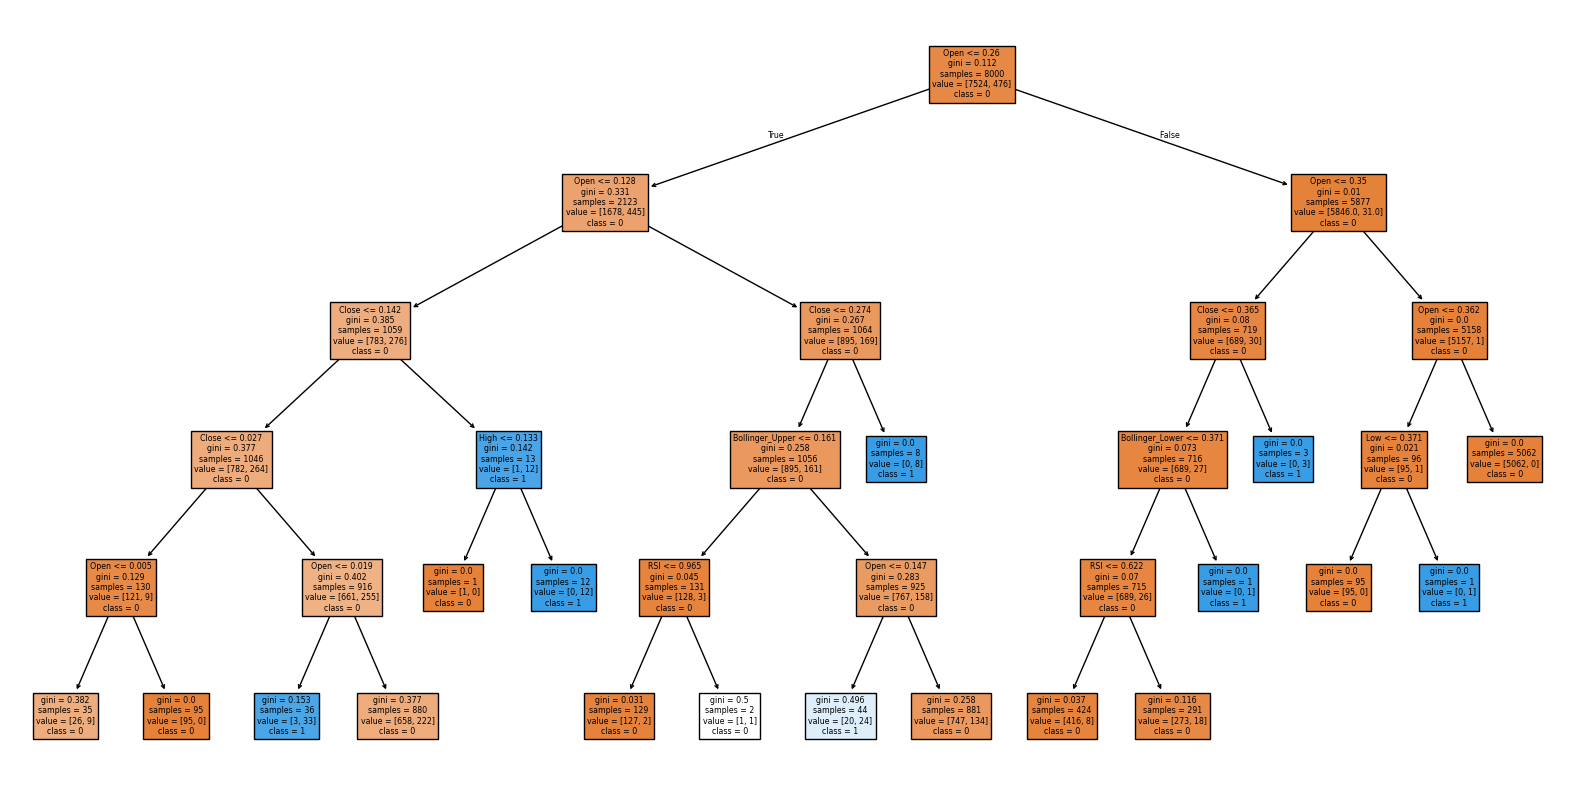

In [23]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree_model = evaluate_model(
    "Decision Tree Classifier",
    decision_tree_model
)

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True
)

plt.show()

In [24]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        C=1,
        kernel="rbf"
    ))
])

svm_model = evaluate_model(
    "Support Vector Machine",
    svm_model
)


 Support Vector Machine
-----------------------------
Accuracy : 0.9405
Precision: 0.88454025
Recall   : 0.9405
F1-Score : 0.9116622004637981
ROC-AUC  : 0.9693574399456752

Confusion Matrix:
[[1881    0]
 [ 119    0]]


D2: Evaluation